In [1]:
try:
    import lenstronomy
except:
    !pip install lenstronomy #tested with version 1.9.0

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import numpy.testing as npt

Deflection Angle

In [2]:
# Lenstronomy computation of deflection angles as seen on the sky

from lenstronomy.LensModel.lens_model import LensModel
#Lens Model instance with a singular isothermal sphere
lens_model_sis = LensModel(lens_model_list=['SIS'])
kwargs_sis = [{'theta_E': 1, 'center_x': 0, 'center_y': 0}]
#angular coordinates where to evaluate the deflection angle
theta_x, theta_y = 1, 0.2
# evaluation of the deflection angles in both directions
alpha_x, alpha_y = lens_model_sis.alpha(theta_x, theta_y, kwargs_sis)

# we can also ray-trace, meaning calculating the source positions are related  by the lens equation
beta_x, beta_y = lens_model_sis.ray_shooting(theta_x, theta_y, kwargs_sis)

# by definition, image position, deflection angle and source positions are related by the lens equation
npt.assert_almost_equal(theta_x - alpha_x, beta_x, decimal=10)
npt.assert_almost_equal(theta_y - alpha_y, beta_y, decimal=10)

In [3]:
# Lenstronomy computation of Lensing example for the same Lens Model
#Evaluation of the lensing potential
psi = lens_model_sis.potential(theta_x, theta_y, kwargs_sis)

In [8]:
# Lenstronomy computation of Fermat potential for the same Lens model 
# Evaluation of the Fermat potential
psi = lens_model_sis.fermat_potential(theta_x, theta_y, kwargs_sis)

Time Delays

In [9]:
#Lenstronomy computation of time Delays
#for this quantity, we require knowlegde of the angular diameter distances, and thus a cosmology as well as the redshift of the deflector and source.
# We are using the astropy cosmology library to define and calculate the cosmological distances

#Create astropy.cosmology instance of input cosmology
from astropy.cosmology import FlatLambdaCDM

# Flat LCDM cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

z_lens = 0.3
z_source = 1.5

# Lens Model instance with a singular isothermal sphere, redshifts and cosmology 
lens_model_sis = LensModel(lens_model_list=['SIS'], z_lens=z_lens, z_source=z_source, cosmo=cosmo)
#Evaluation arrival time relative to a striaght unlensed path (in units of days)
dt = lens_model_sis.arrival_time(theta_x, theta_y, kwargs_sis)

#A negative sign means that the arrival time is BEFORE the unlensed ray
print('Time delay is %s days relative to unlensed path. ' % dt)

Time delay is -23.935322838344838 days relative to unlensed path. 


Distortions and magnification

In [10]:
#Lenstronomy commands to calculate distortion components

#Hessian; second derivate of the potential 
psi_xx, psi_xy, psi_yx, psi_yy = lens_model_sis.hessian(theta_x, theta_y, kwargs_sis)
#convergence
kappa = lens_model_sis.kappa(theta_x, theta_y, kwargs_sis)
#shear
gamma1, gamma2 = lens_model_sis.gamma(theta_x, theta_y, kwargs_sis)
#magnification
mu = lens_model_sis.magnification(theta_x, theta_y, kwargs_sis)

#and here we check whether the definitions are correct
npt.assert_almost_equal(kappa, 1/2. * (psi_xx + psi_yy), decimal=10)
npt.assert_almost_equal(gamma1, 1/2. * (psi_xx - psi_yy), decimal=10)
npt.assert_almost_equal(gamma2, psi_xy, decimal=10)
npt.assert_almost_equal(mu, 1 / ((1-kappa)**2 - gamma1**2 - gamma2**2), decimal=10)

Lensing Effect.   
We are setting up a singular isothermal ellipse (SIE) model with a constant external shear field and illustrate the lensing quantities we have introduced above.

In [7]:
import inspect
from lenstronomy.Util import util
from lenstronomy.Plots import plot_util
from lenstronomy.Plots.lens_plot import lens_model_plot, arrival_time_surface

print(inspect.signature(lens_model_plot))
print(inspect.signature(arrival_time_surface))

print(inspect.signature(plot_util.CausticCriticalKwargs))

(ax, lens_model, kwargs_lens, num_pix=500, delta_pix=0.01, source_pos_x=0, source_pos_y=0, point_source=False, with_convergence=True, coord_center_ra=0, coord_center_dec=0, coord_inverse=False, fast_caustic=True, name_list=None, index=None, kwargs_convergence=None, kwargs_caustics: lenstronomy.Plots.plot_util.CausticCriticalKwargs | None = {}, kwargs_point_source=None)
(ax, lens_model, kwargs_lens, num_pix=500, delta_pix=0.01, source_pos_x=0, source_pos_y=0, point_source=False, n_levels=10, kwargs_caustics: lenstronomy.Plots.plot_util.CausticCriticalKwargs | None = {}, image_color_value=None, letter_font_size=20, name_list=None, **kwargs_contours: 'Unpack[plot_util.PlotKwargs]')


ValueError: no signature found for builtin type <class 'dict'>

In [8]:
import lenstronomy
print(lenstronomy.__version__)

1.14.1


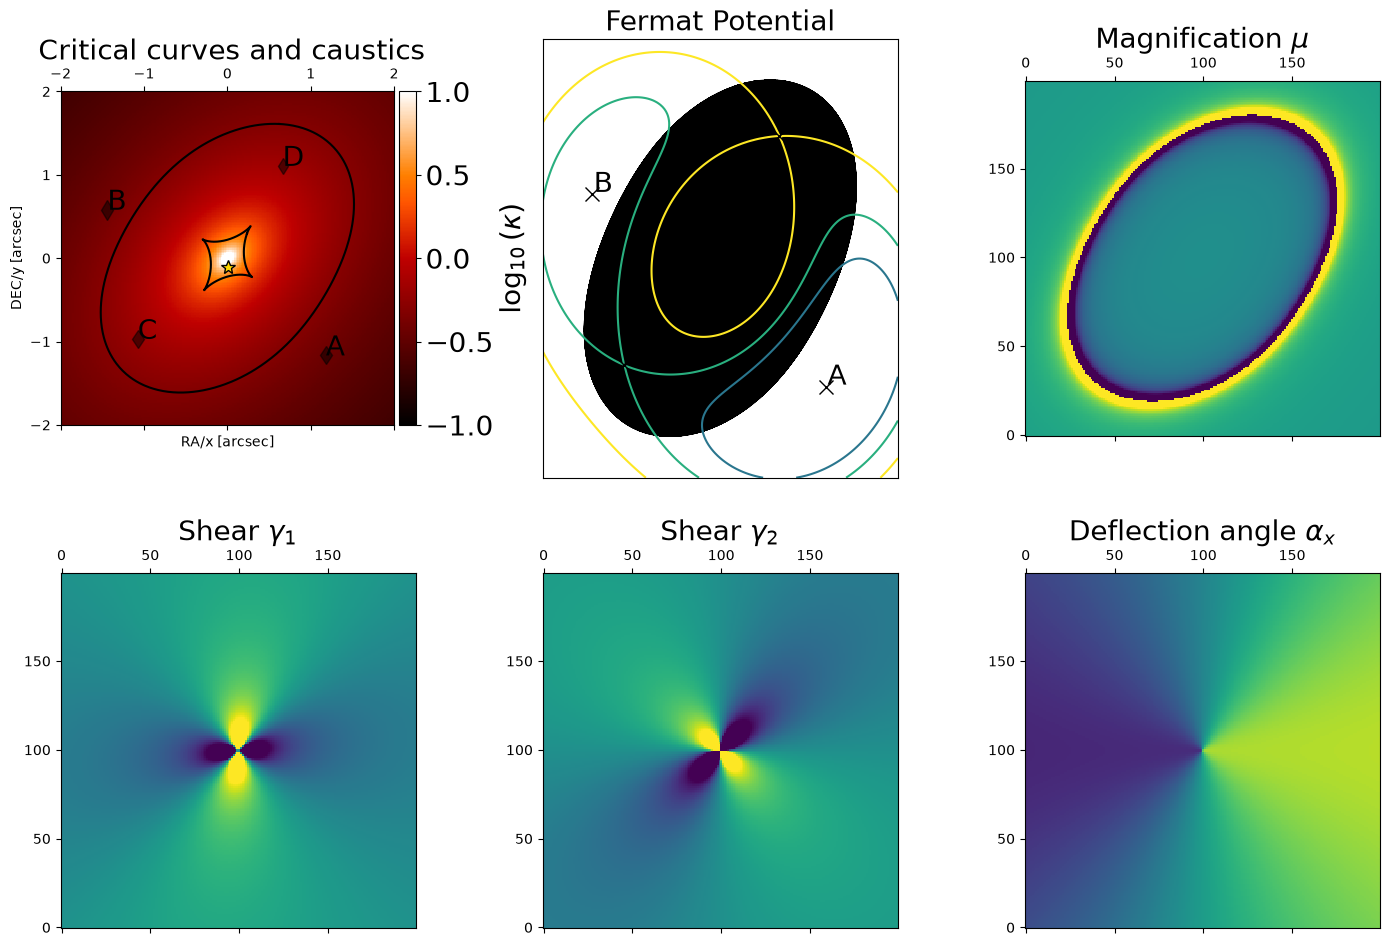

In [11]:
from lenstronomy.Plots.lens_plot import lens_model_plot, arrival_time_surface
from lenstronomy.Util import util

lens_model_sie_shear = LensModel(lens_model_list = ['SIE', 'SHEAR'], z_lens = z_lens, z_source = z_source, cosmo = cosmo)

kwargs_lens_sie_shear = [{'theta_E': 1.5, 'e1': 0, 'e2': 0.2, 'center_x': 0, 'center_y': 0}, #SIE parameters
                         {'gamma1': 0.04, 'gamma2': 0} #shear parameters
                        ]

source_x, source_y = 0.01, -0.1 #source position

#coordinate grid for plotting
num_pix = 200
delta_pix = 0.02

x_grid, y_grid = util.make_grid(num_pix=num_pix, delta_pix=delta_pix)
#x_grid, y_grid = util.make_grid(numPix = num_pix, deltapix = delta_pix)

kwargs_lens_plot = {'fast_caustic': True, 'point_source': True,
                    'with_convergence': True, 'num_pix': num_pix, 'delta_pix': delta_pix}

#kwargs_caustics = {
#    "color_crit": "r",
#    "color_caustic": "b",
#    "points_only": False
#}

f, axex = plt.subplots(2, 3, figsize=(14,10))


#image positions, critical curves and caustics
lens_model_plot(axex[0, 0], lens_model_sie_shear, kwargs_lens_sie_shear,
                         source_pos_x= source_x,
                         source_pos_y= source_y, kwargs_caustics={}, **kwargs_lens_plot)
axex[0, 0].set_title(' Critical curves and caustics', fontsize=20)

arrival_time_surface(axex[0, 1], lens_model_sie_shear, kwargs_lens_sie_shear,
                                source_pos_x= source_x,
                                source_pos_y= source_y,
                                num_pix= num_pix, delta_pix= delta_pix, point_source= True)
axex[0, 1].set_title('Fermat Potential', fontsize=20)

mu = lens_model_sie_shear.magnification(x_grid, y_grid, kwargs_lens_sie_shear)
mu = util.array2image(mu)



axex[0, 2].matshow(mu, origin='lower', vmin= -20, vmax= 20)
axex[0, 2].set_title(r'Magnification $\mu$', fontsize=20)

gamma1, gamma2 = lens_model_sie_shear.gamma(x_grid, y_grid, kwargs_lens_sie_shear)

axex[1, 0].matshow(util.array2image(gamma1), origin='lower', vmin=-2, vmax=2)
axex[1, 0].set_title(r'Shear $\gamma_1$', fontsize=20)

axex[1, 1].matshow(util.array2image(gamma2), origin='lower', vmin=-2, vmax=2)
axex[1, 1].set_title(r'Shear $\gamma_2$', fontsize=20)


alpha_x, alpha_y = lens_model_sie_shear.alpha(x_grid, y_grid, kwargs_lens_sie_shear)
axex[1, 2].matshow(util.array2image(alpha_x), origin='lower', vmin=-2, vmax=2)
axex[1, 2].set_title(r'Deflection angle $\alpha_x$', fontsize=20)

plt.tight_layout()
plt.show()

In [ ]:
mu = lens_model_sie_shear.magnification(
    x_grid,
    y_grid,
    kwargs_lens_sie_shear
)

print(np.nanmin(mu))
print(np.nanmax(mu))

-21198.73478841824
27824.42195093456


In [ ]:
print(type(mu))
print(mu.shape)

print(type(x_grid))
print(x_grid.shape)

print(type(y_grid))
print(y_grid.shape)

<class 'numpy.ndarray'>
(200, 200)
<class 'numpy.ndarray'>
(40000,)
<class 'numpy.ndarray'>
(40000,)


In [ ]:
from lenstronomy.Plots import plot_util

print(plot_util.CausticCriticalKwargs)

<class 'lenstronomy.Plots.plot_util.CausticCriticalKwargs'>


In [ ]:
print(lens_model_plot.__doc__)

Plots a lens model (convergence) and the critical curves and caustics.

:param ax: Matplotlib axes instance
:type ax: matplotlib.axes.Axes
:param lens_model: LensModel() class instance
:type lens_model: LensModel
:param kwargs_lens: lens model keyword argument list
:type kwargs_lens: list or dict
:param num_pix: total number of pixels (for convergence map)
:type num_pix: int
:param delta_pix: width of pixel (total frame size is delta_pix x num_pix)
:type delta_pix: float
:param source_pos_x: X-position of point source (image positions computed by
    the lens equation)
:type source_pos_x: float
:param source_pos_y: Y-position of point source (image positions computed by
    the lens equation)
:type source_pos_y: float
:param point_source: If True, illustrates and computes the image positions of
    the point source
:type point_source: bool
:param with_convergence: If True, illustrates the convergence map
:type with_convergence: bool
:param coord_center_ra: X-coordinate of the center of

In [ ]:
print(theta_x)
print(theta_y)

print(np.min(kappa))
print(np.max(kappa))

print(np.nanmin(mu))
print(np.nanmax(mu))

[ 1.18091995 -1.43884102 -1.07523185  0.66265871]
[-1.16610848  0.5810335  -0.97001548  1.10717226]
0.49029033784546006
0.49029033784546006
-21198.73478841824
27824.42195093456


In [ ]:
detA = 1/mu

print(np.min(detA))
print(np.max(detA))

-128.9051235937104
0.5632113549011306


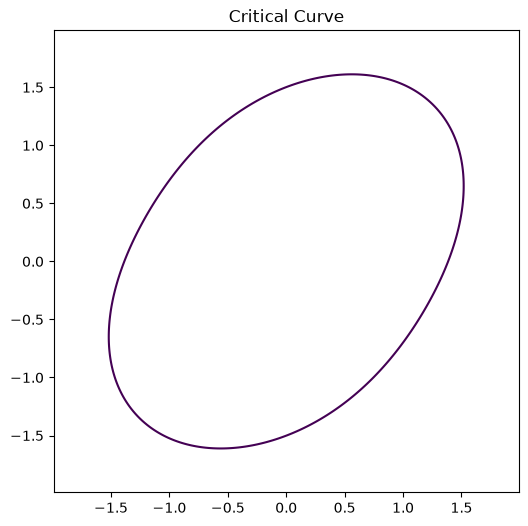

In [ ]:
plt.figure(figsize=(6,6))

plt.contour(
    util.array2image(x_grid),
    util.array2image(y_grid),
    util.array2image(detA),
    levels=[0],
)

plt.title("Critical Curve")
plt.show()